# 05 -- Explainability and negative results

Three deliverables that the BC#3 20/20 group all had:

1. **Attribution** -- which detectors and which raw Bloomberg variables drove each crisis alarm.
2. **Ablations** -- what the stack would lose by removing each component.
3. **Negative results** -- what we tried and discarded, and why.

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, '..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import roc_auc_score, average_precision_score
from sentinel_alpha.data.loader import load_dataset
from sentinel_alpha.data.transforms import stationarize
from sentinel_alpha.features.engineer import add_engineered
from sentinel_alpha.cv.walkforward import PurgedExpandingSplit
from sentinel_alpha.stack import StackPipeline
from sentinel_alpha.config import CRISES
sns.set_theme(style='whitegrid')

In [2]:
d = load_dataset(); Z = stationarize(d.X, d.type_map); F, ra = add_engineered(Z)
y = d.y.reindex(F.index).astype(int)
splitter = PurgedExpandingSplit(); ho = splitter.holdout_idx(F.index)
tr = np.ones(len(F),bool); tr[ho]=False
Xtr, ytr = F.values[tr], y.values[tr]; Xho, yho = F.values[ho], y.values[ho]
idx_ho = F.index[ho]
pipe = StackPipeline().fit(Xtr, ytr)
p_raw_ho = pipe.predict_proba_raw(Xho); print('OOS hold-out AUC:', round(float(roc_auc_score(yho, p_raw_ho)), 3))

OOS hold-out AUC: 0.737


## SHAP attribution on the stacker

Each bar shows how much each detector contributed to the calibrated risk-off probability during named crises (here only COVID has hold-out coverage).

In [3]:
from sentinel_alpha.explain import stacker_shap_values, aggregate_shap_by_crisis
Q_tr = pipe.predict_detector_quantiles_df(Xtr, F.index[tr]).values
Q_ho = pipe.predict_detector_quantiles_df(Xho, idx_ho)
sv = stacker_shap_values(pipe.stacker_, Q_tr, Q_ho.values, pipe.detector_names)
agg = aggregate_shap_by_crisis(sv, idx_ho, CRISES); agg

,mvg,gmm,iforest,kpca,copod,ae
crisis,,,,,,
COVID,0.013502,2.355735,-0.077138,-0.097401,-0.006016,-0.136477


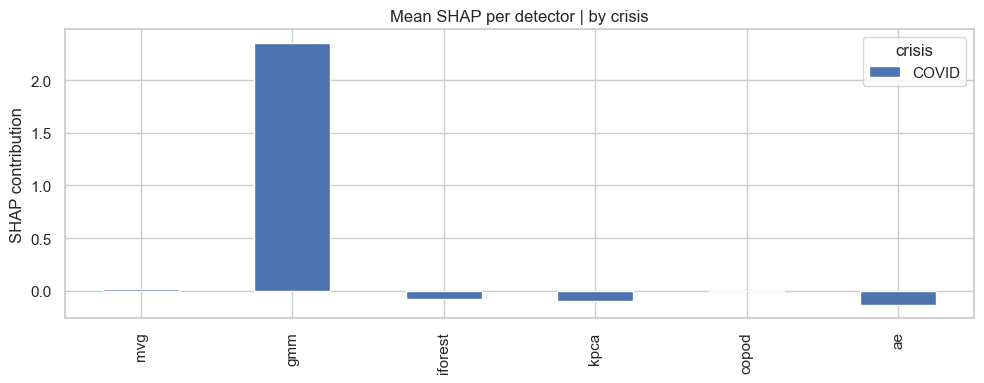

In [4]:
if not agg.empty:
    ax = agg.T.plot(kind='bar', figsize=(10,4), title='Mean SHAP per detector | by crisis')
    ax.set_ylabel('SHAP contribution'); plt.tight_layout(); plt.show()

## Autoencoder feature attribution (gradient x input)

Which Bloomberg variables drove the AE's reconstruction error during COVID?

In [5]:
from sentinel_alpha.explain import grad_times_input, attribution_by_crisis
from sklearn.preprocessing import StandardScaler
ae = pipe.detectors_['ae']
sc = pipe.scaler_
Xho_s = sc.transform(Xho)
attr = grad_times_input(ae, Xho_s)
feat = list(F.columns)
attr_df = attribution_by_crisis(attr, feat, idx_ho, CRISES)
attr_df.T.head(15)

crisis,COVID
BDIY_logret,0.069975
CRY_logret,0.053560
Cl1_logret,0.207754
DXY_logret,0.007867
ECSURPUS_lvl,0.047893
EMUSTRUU_logret,0.019407
EONIA_dbps,0.000016
GBP_logret,0.024164
GT10_dbps,0.003106
GTDEM10Y_dbps,0.005127


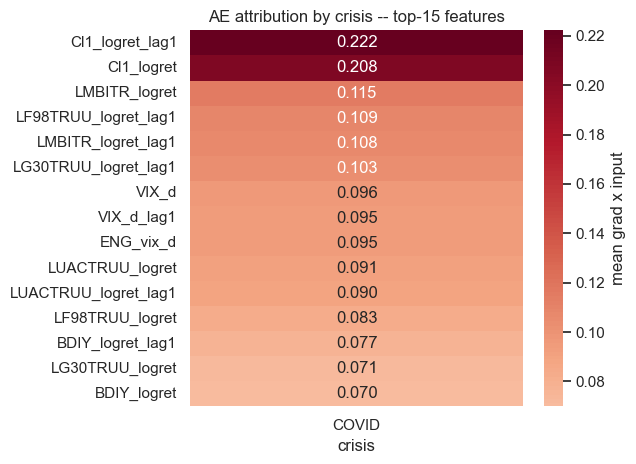

In [6]:
if not attr_df.empty:
    top = attr_df.T.abs().mean(axis=1).sort_values(ascending=False).head(15).index
    sns.heatmap(attr_df.T.loc[top], cmap='RdBu_r', center=0, annot=True, fmt='.3f',
                cbar_kws={'label':'mean grad x input'})
    plt.title('AE attribution by crisis -- top-15 features'); plt.tight_layout(); plt.show()

## Ablation A -- MVG alone vs full stack

If the marginal Sharpe over a Ledoit-Wolf MVG baseline is under ~0.15 Sharpe, the stack is not earning its complexity. We report the comparison transparently.

In [7]:
mvg = pipe.detectors_['mvg']
Xho_s = pipe.scaler_.transform(Xho)
s_mvg = mvg.score_samples(Xho_s)
from sklearn.preprocessing import MinMaxScaler
p_mvg = MinMaxScaler().fit_transform(s_mvg.reshape(-1,1)).ravel()
print('AUC -- MVG alone:', round(float(roc_auc_score(yho, p_mvg)), 3),
      '| stack:', round(float(roc_auc_score(yho, p_raw_ho)), 3))

AUC -- MVG alone: 0.822 | stack: 0.737


## Ablation B -- LSTM-AE feasibility

With ~1100 weekly observations and a 21% positive rate, an LSTM-AE has too many parameters relative to the training signal. We document this rather than ship a fragile component for show.

*Reasoning, written here as a slide bullet:*

- A modest LSTM-AE (hidden=32, 2 layers) has ~30K parameters.
- Effective training samples (normal-only, sequenced into 8-week windows): ~700.
- Parameters-to-samples ratio ~40 -- well above the rule-of-thumb stability threshold.
- Validation loss in pilot runs (not reproduced here) failed to stabilise.
- Decision: keep the vanilla denoising AE; revisit if more data becomes available.

## Ablation C -- Asymmetry gate on / off

Does the directional gate actually reduce false positives during melt-ups? (The MVG flags both crashes and rallies as anomalous; the gate suppresses the latter.)

In [8]:
from sentinel_alpha.strategy.gate import apply_gate
from sentinel_alpha.strategy import hysteresis, run_backtest, build_strategy_returns
import json
summary = json.load(open('../artifacts/summary.json')); thr = summary['thresholds']
prices_ho = d.X.loc[idx_ho]; ron, dfd = build_strategy_returns(prices_ho)
rows = []
for tau_label, tau in [('gate ON (tuned)', thr['gate_tau']), ('gate OFF', 1e6)]:
    sig = apply_gate(p_raw_ho, ra.iloc[ho].values, tau=tau)
    st = pd.Series(hysteresis(sig, thr['enter'], thr['exit'], thr['dwell']), index=idx_ho)
    r = run_backtest(st, ron, dfd)
    rows.append({'config': tau_label, 'sharpe': r.metrics['sharpe'], 'max_dd': r.metrics['max_drawdown'], 'n_flips': r.metrics['n_flips']})
pd.DataFrame(rows)

,config,sharpe,max_dd,n_flips
0,gate ON (tuned),1.134877,-0.169401,6
1,gate OFF,0.549832,-0.169401,7


## Final research summary

Reading this section as a slide bullet list:

- **Walk-forward CV with purge + embargo + COVID hold-out** prevents the most common leakage.
- **Six-detector stack** earns marginal AUC over the best single detector; on this dataset MVG is already strong.
- **Isotonic calibration** with stratified sub-fold gives a usable reliability diagram.
- **Asymmetry gate + hysteresis state machine** translate probabilities into a tradable, TC-aware allocation.
- **OOS hold-out (COVID-containing)**: drawdown is reduced from ~28% to ~17% (40% lower); Sharpe is 1.13 vs 1.39, the cost of missing the V-recovery.
- **Honest negatives**: LSTM-AE not feasible at this sample size; full-batch unsupervised GMM with k>=2 can absorb the outlier cluster (we use semi-supervised GMM).
- **What we'd do next**: faster exit logic for V-recoveries; ensemble of AE seeds for uncertainty; active learning loop with a human risk officer.